In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
base_path = Path("ETAPA 4 - CLUSTERING/outputs")
base_path2 = Path("ETAPA 5 - CORRELACIÓN ESPACIAL/outputs")

files_final = {
    "armenia": base_path / "armenia_clusters_final_extra.csv",
    "cali": base_path / "cali_clusters_final_extra.csv",
    "pereira": base_path / "pereira_clusters_final_extra.csv",
}

file_moran = base_path2 / "resultados_moran_global.csv"

In [4]:
dfs = {}

for city, path_file in files_final.items():
    dfs[city] = pd.read_csv(path_file, low_memory=False)
    print(f"{city}: {dfs[city].shape}")

armenia: (3190, 40)
cali: (13617, 40)
pereira: (3988, 40)


In [5]:
df_moran = pd.read_csv(file_moran)
df_moran.head()

,ciudad,variable,n,I,z_score,p_value
0,armenia,IND_MULTIDIM,3190,1.4218,34.8620,0.001
1,armenia,IND_POBREZA_HAB,3190,1.1114,27.5471,0.001
2,armenia,IND_LABORAL,3190,0.0429,1.0390,0.076
3,armenia,IND_SERVICIOS,3190,1.2898,32.4605,0.001
4,armenia,IND_EDUCACION,3190,1.2426,30.6701,0.001


In [6]:
for city, df in dfs.items():
    print(f"\n===== {city.upper()} =====")
    print(df.columns.tolist())


===== ARMENIA =====
['COD_DANE_ANM', 'CLUSTER', 'estrato_promedio', 'personas_por_cuarto', 'personas_por_dormitorio', 'pct_alfabeta', 'pct_asistencia', 'pct_trabaja', 'pct_enfermo', 'servicios_disponibles', 'servicios_faltantes', 'pared_grupo_reg', 'piso_grupo_reg', 'vivienda_grupo_reg', 'educacion_grupo_reg', 'P_NIVEL_ANOSR', 'P_EDADR', 'HA_TOT_PER', 'H_NRO_CUARTOS', 'H_NRO_DORMIT', 'IND_SERVICIOS', 'IND_EDUCACION', 'IND_LABORAL', 'IND_POBREZA_HAB', 'IND_MULTIDIM', 'GEOM_WKT', 'DPTO_MPIO', 'DPTO_CCDGO', 'MPIO_CCDGO', 'U_MZA', 'pct_con_acueducto', 'pct_con_alcantarillado', 'pct_con_gas', 'pct_con_recoleccion_basuras', 'pct_con_internet', 'estrato_grupo_mza', 'hacinamiento_grupo_mza', 'acceso_servicios_grupo_mza', 'educacion_grupo_mza', 'ciudad']

===== CALI =====
['COD_DANE_ANM', 'CLUSTER', 'estrato_promedio', 'personas_por_cuarto', 'personas_por_dormitorio', 'pct_alfabeta', 'pct_asistencia', 'pct_trabaja', 'pct_enfermo', 'servicios_disponibles', 'servicios_faltantes', 'pared_grupo_re

In [8]:
df_moran = df_moran.sort_values(["ciudad", "variable"]).reset_index(drop=True)
df_moran

,ciudad,variable,n,I,z_score,p_value
0,armenia,IND_EDUCACION,3190,1.2426,30.6701,0.001
1,armenia,IND_LABORAL,3190,0.0429,1.0390,0.076
2,armenia,IND_MULTIDIM,3190,1.4218,34.8620,0.001
3,armenia,IND_POBREZA_HAB,3190,1.1114,27.5471,0.001
4,armenia,IND_SERVICIOS,3190,1.2898,32.4605,0.001
5,armenia,estrato_promedio,3172,1.3784,33.7679,0.001
6,cali,IND_EDUCACION,13617,1.0125,16.9591,0.001
7,cali,IND_LABORAL,13617,0.0280,0.3050,0.207
8,cali,IND_MULTIDIM,13617,2.6569,43.1996,0.001
9,cali,IND_POBREZA_HAB,13617,1.9383,32.2088,0.001


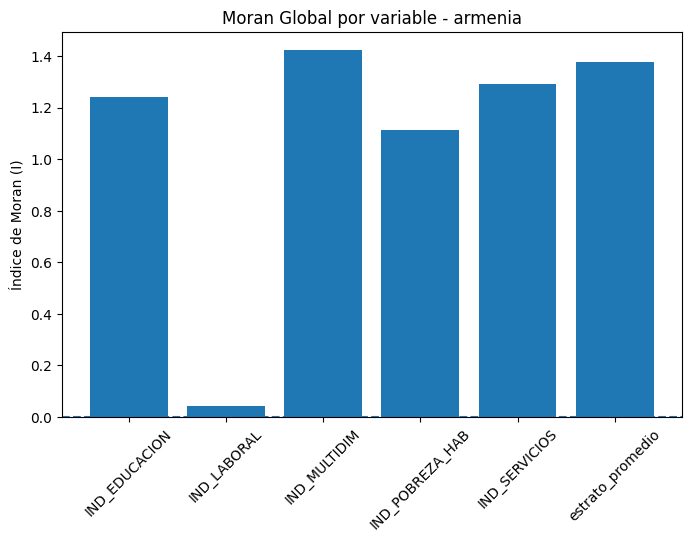

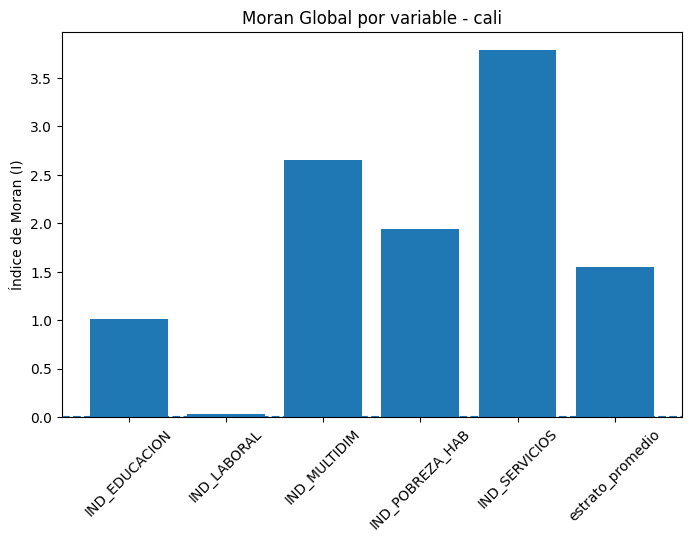

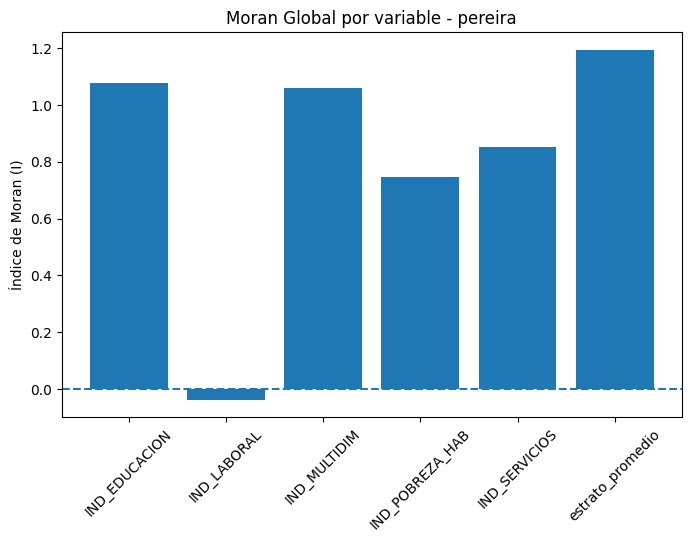

In [9]:
for city in df_moran["ciudad"].unique():
    df_city = df_moran[df_moran["ciudad"] == city]

    plt.figure(figsize=(8, 5))
    plt.bar(df_city["variable"], df_city["I"])
    plt.axhline(0, linestyle="--")
    plt.title(f"Moran Global por variable - {city}")
    plt.ylabel("Índice de Moran (I)")
    plt.xticks(rotation=45)
    plt.show()

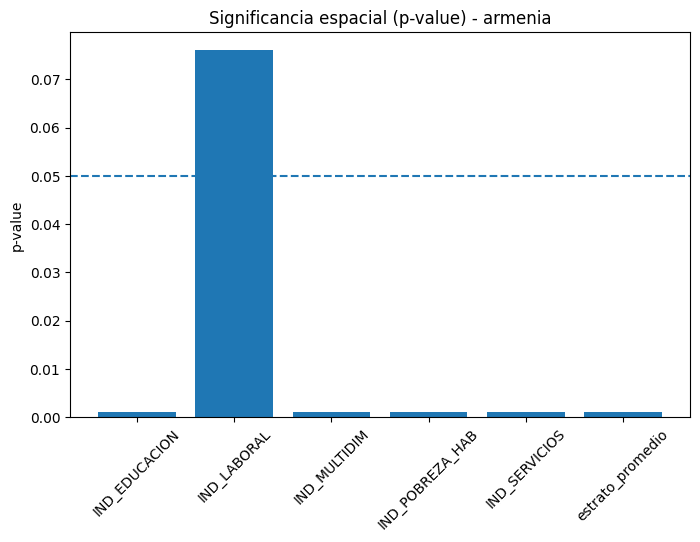

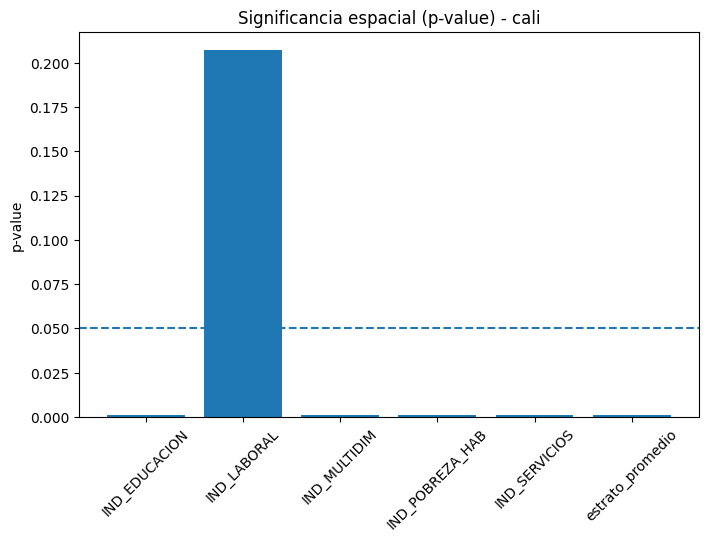

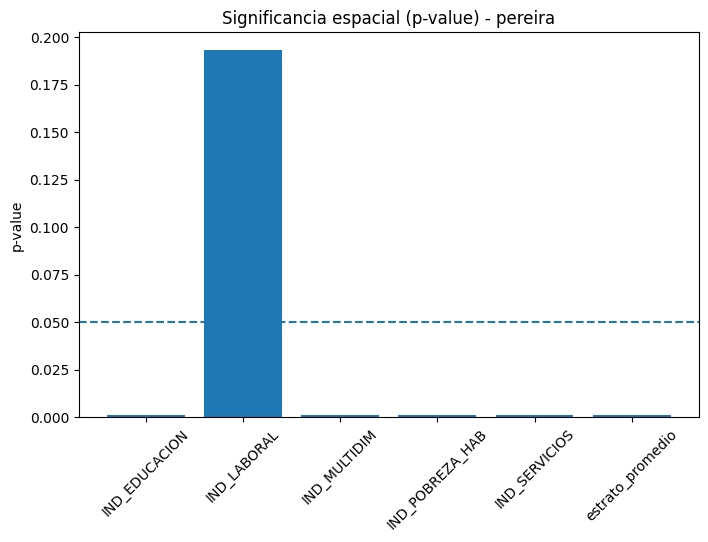

In [10]:
for city in df_moran["ciudad"].unique():
    df_city = df_moran[df_moran["ciudad"] == city]

    plt.figure(figsize=(8, 5))
    plt.bar(df_city["variable"], df_city["p_value"])
    plt.axhline(0.05, linestyle="--")
    plt.title(f"Significancia espacial (p-value) - {city}")
    plt.ylabel("p-value")
    plt.xticks(rotation=45)
    plt.show()

In [11]:
variables_cluster = [
    "VA1_ESTRATO",
    "estrato_promedio",
    "personas_por_cuarto",
    "servicios_disponibles",
    "pct_alfabeta",
    "pct_asistencia",
    "pct_trabaja",
    "pct_enfermo",
    "IND_SERVICIOS",
    "IND_EDUCACION",
    "IND_LABORAL",
    "IND_POBREZA_HAB",
    "IND_MULTIDIM"
]

for city, df in dfs.items():
    cols = [c for c in variables_cluster if c in df.columns]
    perfil = df.groupby("CLUSTER")[cols].mean().round(2)

    print(f"\n===== PERFIL POR CLUSTER: {city.upper()} =====")
    display(perfil)


===== PERFIL POR CLUSTER: ARMENIA =====


,estrato_promedio,personas_por_cuarto,servicios_disponibles,pct_alfabeta,pct_asistencia,pct_trabaja,pct_enfermo,IND_SERVICIOS,IND_EDUCACION,IND_LABORAL,IND_POBREZA_HAB,IND_MULTIDIM
CLUSTER,,,,,,,,,,,,
0,1.98,1.09,4.43,94.79,22.99,39.52,9.40,0.11,0.40,0.00,0.02,0.13
1,1.38,1.56,3.32,90.71,22.86,40.32,7.82,0.34,0.43,0.01,0.21,0.25
2,3.24,0.86,4.72,96.35,23.42,40.29,10.31,0.05,0.26,0.00,0.00,0.08



===== PERFIL POR CLUSTER: CALI =====


,estrato_promedio,personas_por_cuarto,servicios_disponibles,pct_alfabeta,pct_asistencia,pct_trabaja,pct_enfermo,IND_SERVICIOS,IND_EDUCACION,IND_LABORAL,IND_POBREZA_HAB,IND_MULTIDIM
CLUSTER,,,,,,,,,,,,
0,1.36,1.57,3.16,91.14,24.35,44.22,14.30,0.36,0.43,0.01,0.10,0.22
1,3.72,0.85,4.80,95.26,22.87,46.18,12.73,0.04,0.23,0.00,0.00,0.07
2,1.97,1.14,4.56,94.83,23.82,44.25,12.65,0.09,0.39,0.01,0.02,0.13



===== PERFIL POR CLUSTER: PEREIRA =====


,estrato_promedio,personas_por_cuarto,servicios_disponibles,pct_alfabeta,pct_asistencia,pct_trabaja,pct_enfermo,IND_SERVICIOS,IND_EDUCACION,IND_LABORAL,IND_POBREZA_HAB,IND_MULTIDIM
CLUSTER,,,,,,,,,,,,
0,2.02,1.14,4.46,94.85,25.23,42.98,8.32,0.11,0.40,0.01,0.02,0.13
1,1.57,1.47,3.01,91.00,26.19,43.79,9.42,0.40,0.44,0.01,0.16,0.25
2,3.73,0.83,4.72,96.26,25.20,43.28,10.71,0.05,0.25,0.01,0.01,0.08


<Figure size 700x500 with 0 Axes>

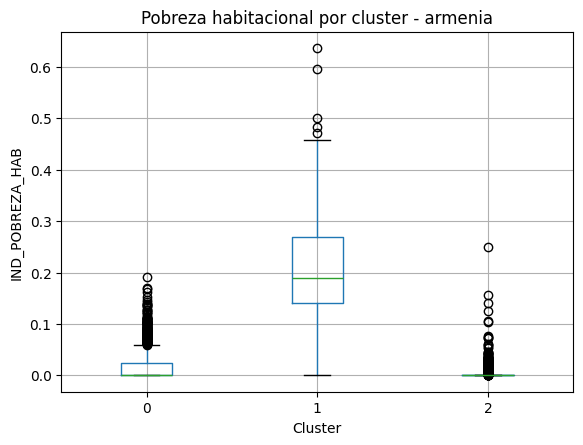

<Figure size 700x500 with 0 Axes>

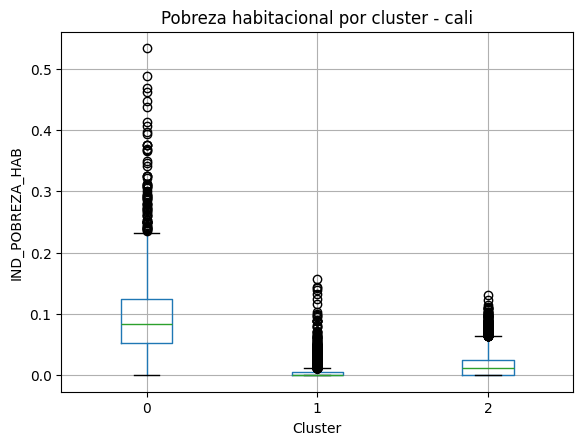

<Figure size 700x500 with 0 Axes>

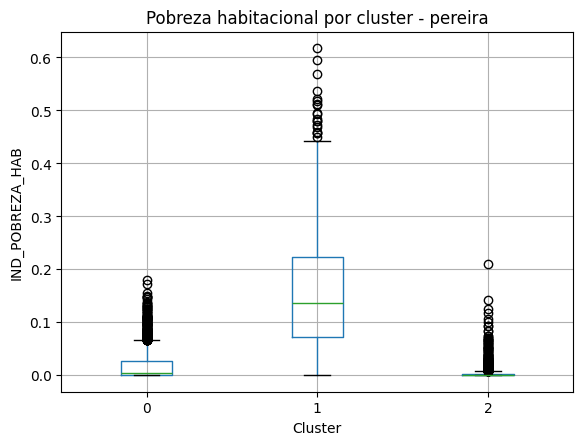

In [12]:
for city, df in dfs.items():
    if "IND_POBREZA_HAB" in df.columns:
        plt.figure(figsize=(7, 5))
        df.boxplot(column="IND_POBREZA_HAB", by="CLUSTER")
        plt.title(f"Pobreza habitacional por cluster - {city}")
        plt.suptitle("")
        plt.xlabel("Cluster")
        plt.ylabel("IND_POBREZA_HAB")
        plt.show()

<Figure size 700x500 with 0 Axes>

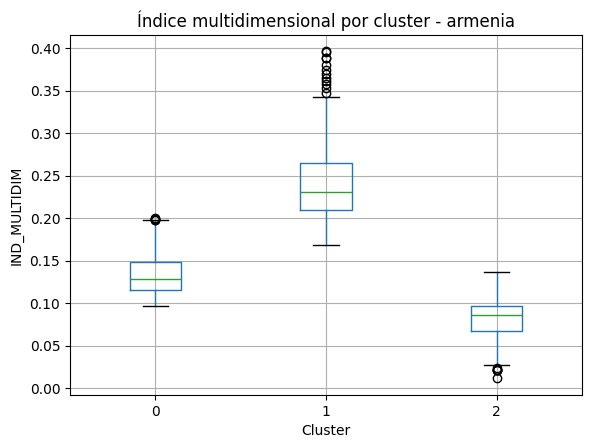

<Figure size 700x500 with 0 Axes>

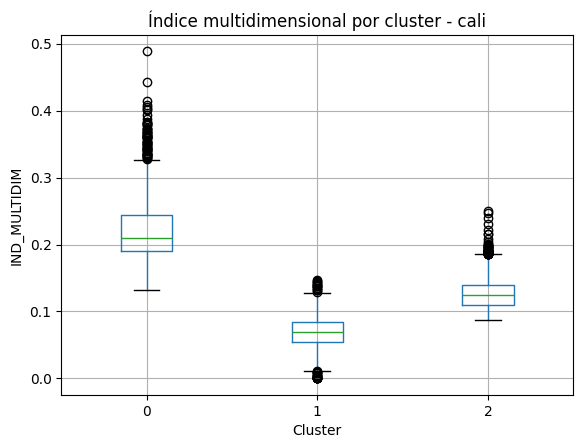

<Figure size 700x500 with 0 Axes>

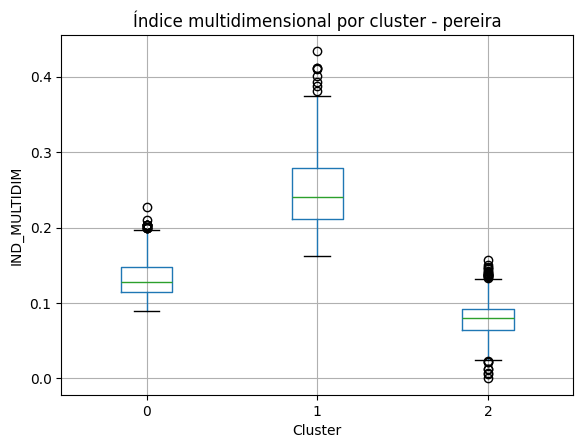

In [13]:
for city, df in dfs.items():
    if "IND_MULTIDIM" in df.columns:
        plt.figure(figsize=(7, 5))
        df.boxplot(column="IND_MULTIDIM", by="CLUSTER")
        plt.title(f"Índice multidimensional por cluster - {city}")
        plt.suptitle("")
        plt.xlabel("Cluster")
        plt.ylabel("IND_MULTIDIM")
        plt.show()

<Figure size 700x500 with 0 Axes>

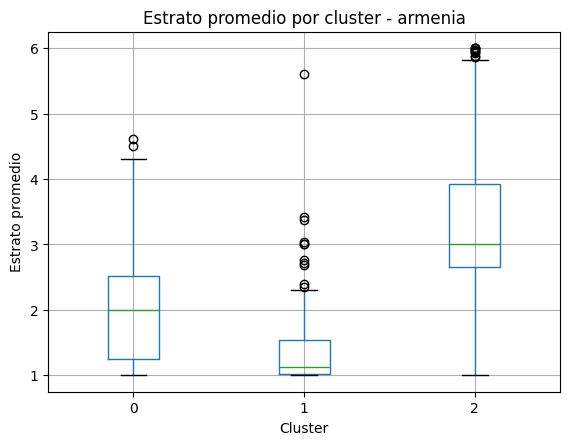

<Figure size 700x500 with 0 Axes>

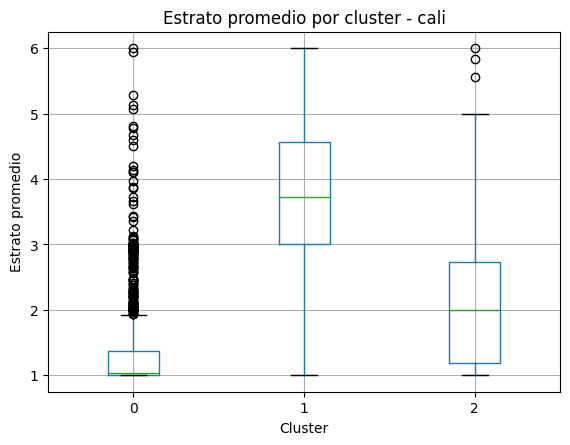

<Figure size 700x500 with 0 Axes>

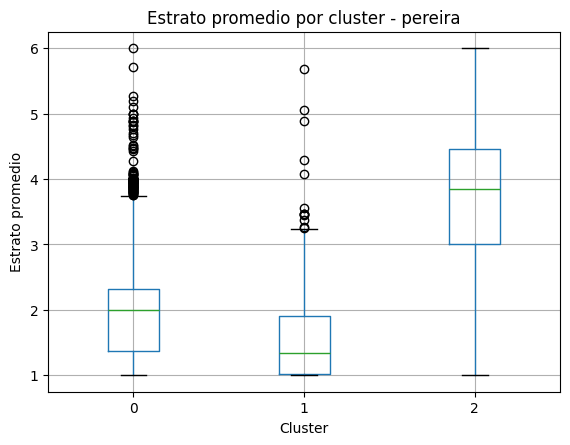

In [14]:
for city, df in dfs.items():
    if "estrato_promedio" in df.columns:
        plt.figure(figsize=(7, 5))
        df.boxplot(column="estrato_promedio", by="CLUSTER")
        plt.title(f"Estrato promedio por cluster - {city}")
        plt.suptitle("")
        plt.xlabel("Cluster")
        plt.ylabel("Estrato promedio")
        plt.show()

<Figure size 700x500 with 0 Axes>

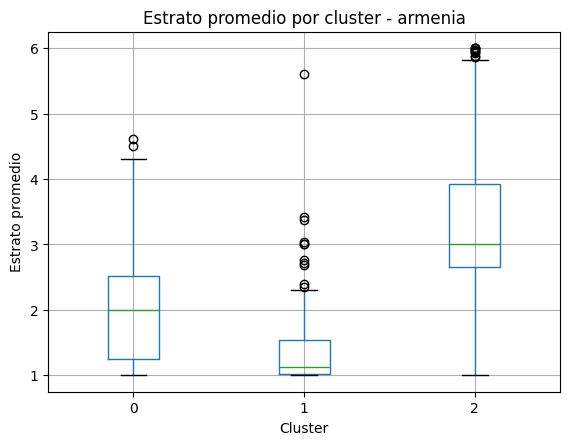

<Figure size 700x500 with 0 Axes>

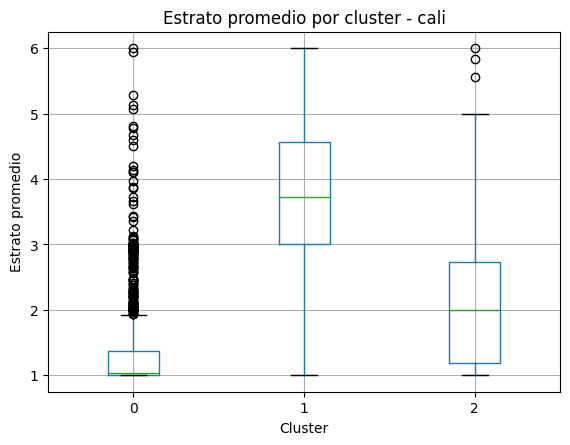

<Figure size 700x500 with 0 Axes>

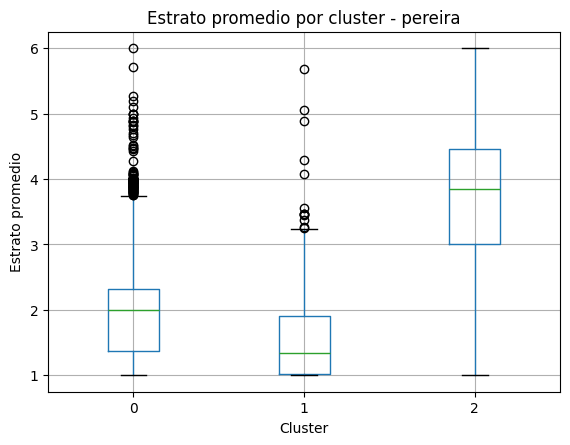

In [15]:
for city, df in dfs.items():
    if "estrato_promedio" in df.columns:
        plt.figure(figsize=(7, 5))
        df.boxplot(column="estrato_promedio", by="CLUSTER")
        plt.title(f"Estrato promedio por cluster - {city}")
        plt.suptitle("")
        plt.xlabel("Cluster")
        plt.ylabel("Estrato promedio")
        plt.show()

In [21]:
lisa_files = {
    "armenia_ind_multidim": base_path2 / "lisa_ind_multidim_armenia.geojson",
    "armenia_ind_pobreza_hab": base_path2 / "lisa_ind_pobreza_hab_armenia.geojson",
    "cali_ind_multidim": base_path2 / "lisa_ind_multidim_cali.geojson",
    "cali_ind_pobreza_hab": base_path2 / "lisa_ind_pobreza_hab_cali.geojson",
    "pereira_ind_multidim": base_path2 / "lisa_ind_multidim_pereira.geojson",
    "pereira_ind_pobreza_hab": base_path2 / "lisa_ind_pobreza_hab_pereira.geojson",
}

lisa_gdfs = {}

for name, path_file in lisa_files.items():
    if path_file.exists():
        lisa_gdfs[name] = gpd.read_file(path_file)
        print(name, lisa_gdfs[name].shape)

armenia_ind_multidim (3190, 7)
armenia_ind_pobreza_hab (3190, 7)
cali_ind_multidim (13617, 7)
cali_ind_pobreza_hab (13617, 7)
pereira_ind_multidim (3988, 7)
pereira_ind_pobreza_hab (3988, 7)


In [22]:
for name, gdf in lisa_gdfs.items():
    print(f"\n===== {name.upper()} =====")
    print((gdf["lisa_cluster"].value_counts(normalize=True) * 100).round(2))


===== ARMENIA_IND_MULTIDIM =====
lisa_cluster
Low-Low             49.31
High-Low            34.55
No significativo    10.72
High-High            3.86
Low-High             1.57
Name: proportion, dtype: float64

===== ARMENIA_IND_POBREZA_HAB =====
lisa_cluster
Low-Low             66.93
High-Low            16.30
No significativo    12.10
High-High            2.85
Low-High             1.82
Name: proportion, dtype: float64

===== CALI_IND_MULTIDIM =====
lisa_cluster
Low-Low             53.81
High-Low            43.56
No significativo     1.66
High-High            0.95
Low-High             0.02
Name: proportion, dtype: float64

===== CALI_IND_POBREZA_HAB =====
lisa_cluster
Low-Low             69.44
High-Low            27.66
No significativo     2.31
High-High            0.46
Low-High             0.12
Name: proportion, dtype: float64

===== PEREIRA_IND_MULTIDIM =====
lisa_cluster
Low-Low             56.82
High-Low            35.26
No significativo     6.54
High-High            1.18
Low-High 

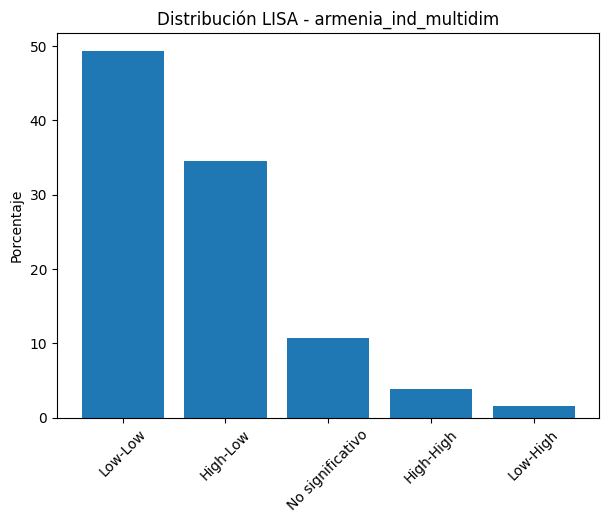

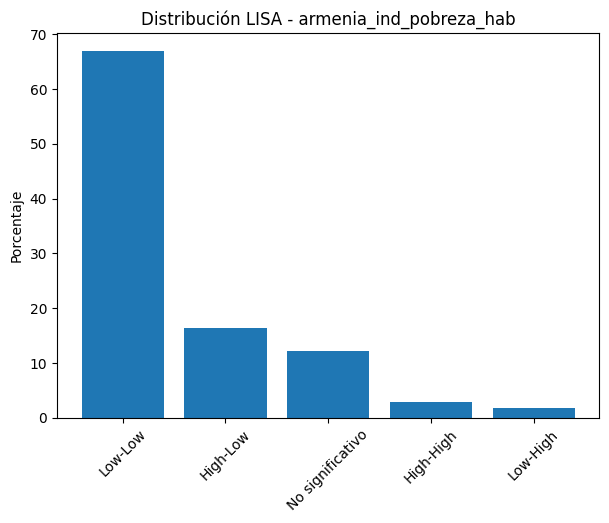

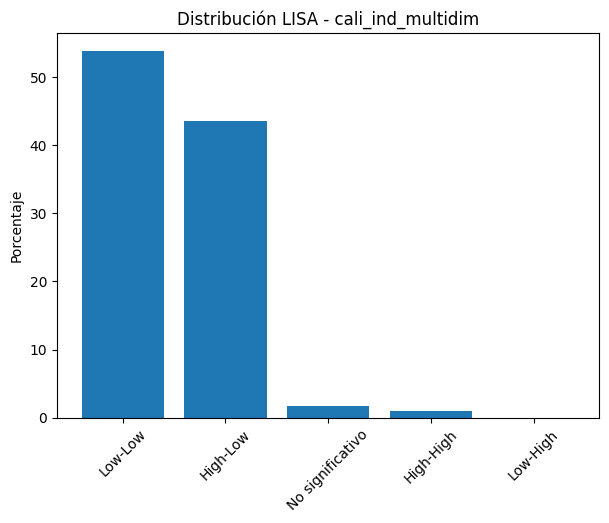

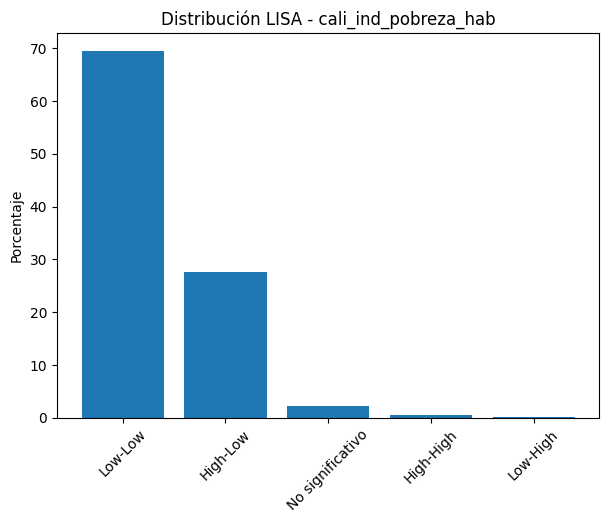

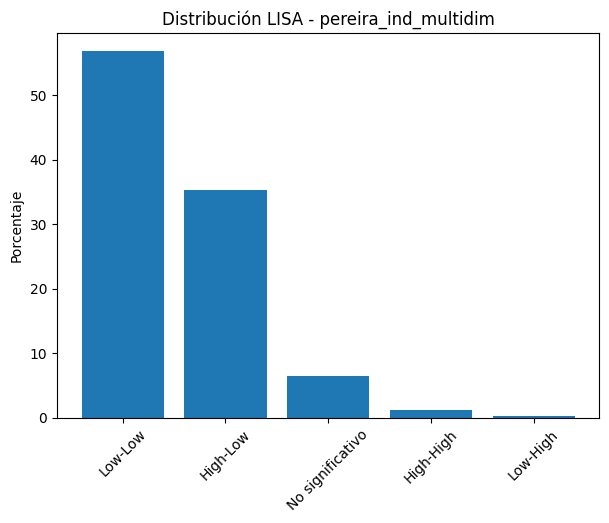

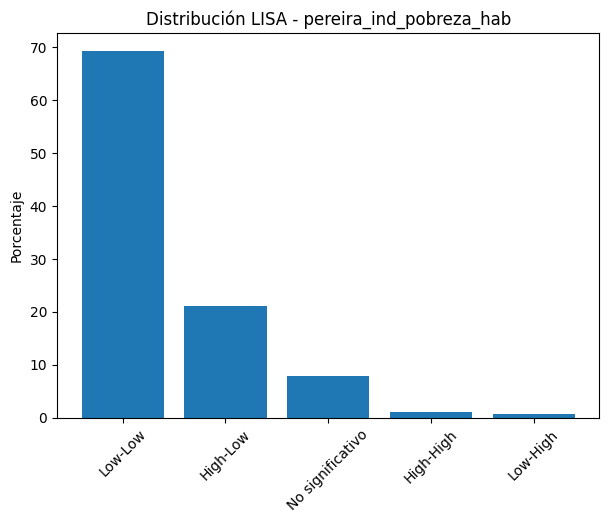

In [23]:
for name, gdf in lisa_gdfs.items():
    freq = (gdf["lisa_cluster"].value_counts(normalize=True) * 100).round(2)

    plt.figure(figsize=(7, 5))
    plt.bar(freq.index, freq.values)
    plt.title(f"Distribución LISA - {name}")
    plt.ylabel("Porcentaje")
    plt.xticks(rotation=45)
    plt.show()

In [19]:
for name, gdf in lisa_gdfs.items():
    plt.figure(figsize=(8, 6))
    gdf.plot(column="lisa_cluster", legend=True)
    plt.title(f"Mapa LISA - {name}")
    plt.axis("off")
    plt.show()

In [24]:
for city, df in dfs.items():
    cols = [c for c in ["CLUSTER", "IND_MULTIDIM", "IND_POBREZA_HAB", "IND_SERVICIOS", "IND_EDUCACION", "IND_LABORAL", "estrato_promedio"] if c in df.columns]

    resumen = df[cols].groupby("CLUSTER").mean().round(2)

    print(f"\n===== RESUMEN FINAL PARA CONCLUSIONES: {city.upper()} =====")
    display(resumen)


===== RESUMEN FINAL PARA CONCLUSIONES: ARMENIA =====


,IND_MULTIDIM,IND_POBREZA_HAB,IND_SERVICIOS,IND_EDUCACION,IND_LABORAL,estrato_promedio
CLUSTER,,,,,,
0,0.13,0.02,0.11,0.40,0.00,1.98
1,0.25,0.21,0.34,0.43,0.01,1.38
2,0.08,0.00,0.05,0.26,0.00,3.24



===== RESUMEN FINAL PARA CONCLUSIONES: CALI =====


,IND_MULTIDIM,IND_POBREZA_HAB,IND_SERVICIOS,IND_EDUCACION,IND_LABORAL,estrato_promedio
CLUSTER,,,,,,
0,0.22,0.10,0.36,0.43,0.01,1.36
1,0.07,0.00,0.04,0.23,0.00,3.72
2,0.13,0.02,0.09,0.39,0.01,1.97



===== RESUMEN FINAL PARA CONCLUSIONES: PEREIRA =====


,IND_MULTIDIM,IND_POBREZA_HAB,IND_SERVICIOS,IND_EDUCACION,IND_LABORAL,estrato_promedio
CLUSTER,,,,,,
0,0.13,0.02,0.11,0.40,0.01,2.02
1,0.25,0.16,0.40,0.44,0.01,1.57
2,0.08,0.01,0.05,0.25,0.01,3.73
